# Day 1–2 · Dataset Exploration

**Goal:** Understand every dataset before writing any logic.  
Run this notebook top-to-bottom. Each cell has a comment explaining *why* we check that specific thing.

**Files needed** (put them in `backend/app/data/`):
- `food_db_final_.csv`
- `Personalized_Diet_Recommendations.csv`
- `detailed_meals_macros_CLEANED.csv`
- `Food_and_Nutrition__.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../backend/app/data/'

# Load all four datasets
food_db  = pd.read_csv(DATA_DIR + 'food_db_final_.csv')
diet_df  = pd.read_csv(DATA_DIR + 'Personalized_Diet_Recommendations.csv')
meals_df = pd.read_csv(DATA_DIR + 'detailed_meals_macros_CLEANED.csv')
fn_df    = pd.read_csv(DATA_DIR + 'Food_and_Nutrition__.csv')

print('food_db_final_                 :', food_db.shape)
print('Personalized_Diet_Recommendations:', diet_df.shape)
print('detailed_meals_macros_CLEANED  :', meals_df.shape)
print('Food_and_Nutrition__           :', fn_df.shape)

food_db_final_                 : (590, 13)
Personalized_Diet_Recommendations: (5000, 30)
detailed_meals_macros_CLEANED  : (1698, 35)
Food_and_Nutrition__           : (1698, 19)


## 1. food_db_final_.csv  
This is our **primary food lookup table** — every food name query from the app will fuzzy-match against this.
We need to know: column names, data types, null counts, and value ranges.

In [2]:
print('=== food_db_final_ columns & dtypes ===')
print(food_db.dtypes)
print()

# Check for nulls — a null calorie or sodium value would break the rule engine
print('=== Null counts ===')
print(food_db.isnull().sum())
# NOTE: 'Unnamed: 12' is an empty artifact column — we'll drop it during preprocessing

=== food_db_final_ columns & dtypes ===
Food_Item             object
Category              object
Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Fiber (g)            float64
Sugars (g)           float64
Sodium (mg)            int64
Cholesterol (mg)     float64
Meal_Type             object
Water_Intake (ml)      int64
Unnamed: 12          float64
dtype: object

=== Null counts ===
Food_Item              0
Category               0
Calories (kcal)        0
Protein (g)            0
Carbohydrates (g)      0
Fat (g)                0
Fiber (g)              0
Sugars (g)             0
Sodium (mg)            0
Cholesterol (mg)       0
Meal_Type              0
Water_Intake (ml)      0
Unnamed: 12          589
dtype: int64


In [3]:
# Check the actual range of each nutrient
# This helps us sanity-check the rule engine thresholds later
nutrient_cols = [
    'Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)',
    'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)'
]
food_db[nutrient_cols].describe().round(1)

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg)
count,590.0,590.0,590.0,590.0,590.0,590.0,590.0,590.0
mean,161.8,7.1,16.6,7.2,1.8,5.7,265.9,25.6
std,148.0,9.2,17.0,8.6,2.1,8.8,320.0,49.6
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,51.2,0.8,2.0,0.2,0.0,0.5,10.0,0.0
50%,116.5,3.0,11.1,4.0,1.0,2.0,140.0,0.0
75%,221.8,8.8,28.0,12.0,3.0,6.0,417.5,35.0
max,740.0,45.0,80.0,40.0,14.0,60.0,1580.0,450.0


In [4]:
# Look at food categories — important for building the ingredient parser
print('=== Food categories ===')
print(food_db['Category'].value_counts())
print()
print('=== Meal types ===')
print(food_db['Meal_Type'].value_counts())

=== Food categories ===
Category
Condiment               93
Vegetable               62
Grain                   49
Beverage                48
Dessert                 35
Fruit                   31
Meal/Processed          27
Protein/Meat            26
Dairy                   23
Meal/Meat               19
Snack/Processed         15
Meal/Pasta              14
Nut                     10
Meal/Vegetarian         10
Meat                     8
Legume                   8
Meal/Vegetable           8
Protein/Fish             8
Grain/Processed          7
Meal/Seafood             6
Protein/Vegetarian       6
Seafood                  6
Protein/Seafood          5
Protein/Dairy            5
Snack                    5
Protein                  4
Meal/Soup                4
Condiment/Dairy          4
Meal/Protein             4
Meal/Grain               4
Beverage/Dairy-Alt       3
Meal/Fish                3
Spice/Condiment          3
Bakery/Snack             2
Meal/Rice                2
Rice/Grain            

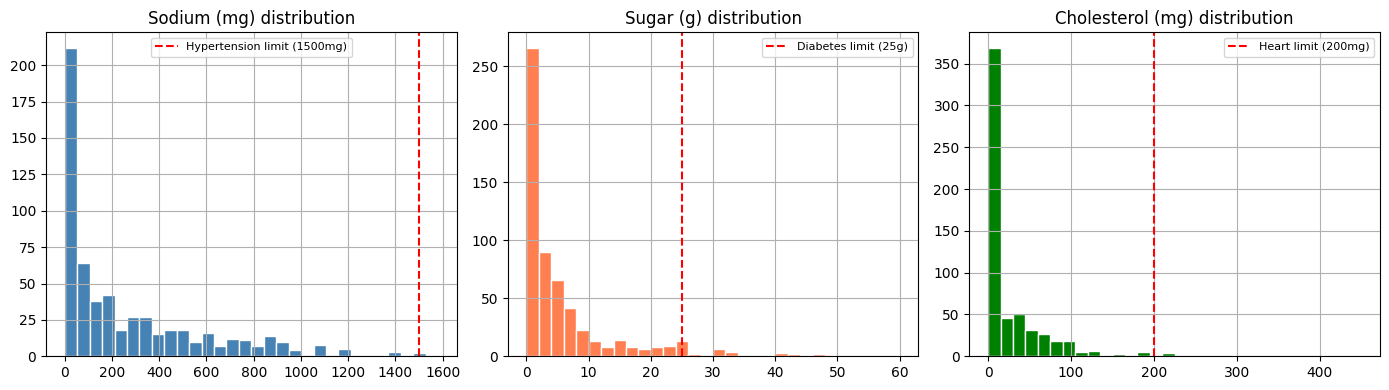

Chart saved.


In [5]:
# Visualize sodium distribution — Hypertension rule depends on this
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

food_db['Sodium (mg)'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Sodium (mg) distribution')
axes[0].axvline(1500, color='red', linestyle='--', label='Hypertension limit (1500mg)')
axes[0].legend(fontsize=8)

food_db['Sugars (g)'].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Sugar (g) distribution')
axes[1].axvline(25, color='red', linestyle='--', label='Diabetes limit (25g)')
axes[1].legend(fontsize=8)

food_db['Cholesterol (mg)'].hist(bins=30, ax=axes[2], color='green', edgecolor='white')
axes[2].set_title('Cholesterol (mg) distribution')
axes[2].axvline(200, color='red', linestyle='--', label='Heart limit (200mg)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../backend/app/data/nutrient_distributions.png', dpi=100)
plt.show()
print('Chart saved.')

## 2. Personalized_Diet_Recommendations.csv  
This is our **medical rules source** — we derive disease-specific nutrient thresholds from it.
Key columns: `Chronic_Disease`, `Allergies`, `Recommended_Calories/Protein/Carbs/Fats`

In [6]:
# Fill NaN with 'None' — 2043 patients have no chronic disease (healthy baseline)
diet_df['Chronic_Disease'] = diet_df['Chronic_Disease'].fillna('None')
diet_df['Allergies']       = diet_df['Allergies'].fillna('None')

print('=== Disease distribution ===')
print(diet_df['Chronic_Disease'].value_counts())
print()
print('=== Allergy distribution ===')
print(diet_df['Allergies'].value_counts())
print()
print('=== Recommended Meal Plans ===')
print(diet_df['Recommended_Meal_Plan'].value_counts())

=== Disease distribution ===
Chronic_Disease
None             2043
Diabetes         1019
Heart Disease     749
Hypertension      693
Obesity           496
Name: count, dtype: int64

=== Allergy distribution ===
Allergies
None                   3497
Lactose Intolerance     556
Nut Allergy             483
Gluten Intolerance      464
Name: count, dtype: int64

=== Recommended Meal Plans ===
Recommended_Meal_Plan
Low-Fat Diet         1313
High-Protein Diet    1255
Balanced Diet        1250
Low-Carb Diet        1182
Name: count, dtype: int64


In [7]:
# Derive data-driven thresholds — this is what populates DISEASE_RULES in medical_rules.py
# We use 75th percentile for max limits (generous upper bound)
# and 25th percentile for min protein (lower bound for adequacy)

print('=== Per-disease recommended nutrient ranges ===')
for disease in ['Diabetes', 'Hypertension', 'Heart Disease', 'Obesity']:
    sub = diet_df[diet_df['Chronic_Disease'] == disease]
    print(f'\n--- {disease} (n={len(sub)}) ---')
    print(f'  Calories  : mean={sub.Recommended_Calories.mean():.0f}  '
          f'75th={sub.Recommended_Calories.quantile(0.75):.0f}')
    print(f'  Protein(g): mean={sub.Recommended_Protein.mean():.0f}  '
          f'25th={sub.Recommended_Protein.quantile(0.25):.0f}')
    print(f'  Carbs(g)  : mean={sub.Recommended_Carbs.mean():.0f}  '
          f'75th={sub.Recommended_Carbs.quantile(0.75):.0f}')
    print(f'  Fats(g)   : mean={sub.Recommended_Fats.mean():.0f}  '
          f'75th={sub.Recommended_Fats.quantile(0.75):.0f}')

=== Per-disease recommended nutrient ranges ===

--- Diabetes (n=1019) ---
  Calories  : mean=2015  75th=2584
  Protein(g): mean=129  25th=94
  Carbs(g)  : mean=244  75th=320
  Fats(g)   : mean=89  75th=118

--- Hypertension (n=693) ---
  Calories  : mean=2045  75th=2641
  Protein(g): mean=129  25th=92
  Carbs(g)  : mean=254  75th=326
  Fats(g)   : mean=91  75th=121

--- Heart Disease (n=749) ---
  Calories  : mean=2064  75th=2614
  Protein(g): mean=129  25th=93
  Carbs(g)  : mean=243  75th=315
  Fats(g)   : mean=91  75th=124

--- Obesity (n=496) ---
  Calories  : mean=2005  75th=2619
  Protein(g): mean=131  25th=93
  Carbs(g)  : mean=249  75th=323
  Fats(g)   : mean=86  75th=120


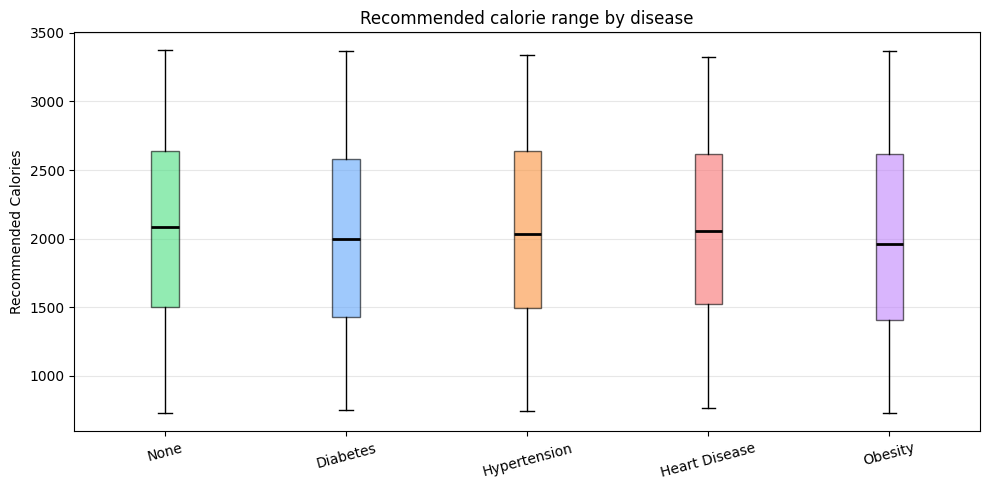

In [8]:
# Visualize how recommended calories differ across diseases
# This confirms our rule engine thresholds are realistic
fig, ax = plt.subplots(figsize=(10, 5))
diseases = ['None', 'Diabetes', 'Hypertension', 'Heart Disease', 'Obesity']
colors   = ['#4ade80', '#60a5fa', '#fb923c', '#f87171', '#c084fc']

for i, (d, c) in enumerate(zip(diseases, colors)):
    subset = diet_df[diet_df['Chronic_Disease'] == d]['Recommended_Calories']
    ax.boxplot(subset, positions=[i], patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))

ax.set_xticks(range(len(diseases)))
ax.set_xticklabels(diseases, rotation=15)
ax.set_ylabel('Recommended Calories')
ax.set_title('Recommended calorie range by disease')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../backend/app/data/calorie_by_disease.png', dpi=100)
plt.show()

## 3. detailed_meals_macros_CLEANED.csv + Food_and_Nutrition__.csv  
These two are our **ML training datasets** — both have identical disease-to-meal mappings,  
just different macro detail levels. We'll merge them in the preprocessing notebook.

In [9]:
# Both have identical Disease columns — confirm before merging
print('=== detailed_meals Disease distribution ===')
print(meals_df['Disease'].value_counts())
print()
print('Shapes match:', meals_df.shape[0] == fn_df.shape[0])

=== detailed_meals Disease distribution ===
Disease
Weight Gain                                                                 1312
Weight Gain, Hypertension, Heart Disease                                     129
Weight Gain, Kidney Disease                                                   91
Weight Gain, Hypertension, Heart Disease, Kidney Disease                      82
Diabetes, Acne, Weight Gain, Hypertension, Heart Disease                      45
Diabetes, Acne, Hypertension, Heart Disease                                   14
Hypertension, Heart Disease                                                    9
Diabetes, Acne, Weight Gain, Hypertension, Heart Disease, Kidney Disease       5
Hypertension, Heart Disease, Kidney Disease                                    4
Kidney Disease                                                                 3
Hypertension, Kidney Disease                                                   2
Diabetes, Acne, Hypertension, Kidney Disease             

In [10]:
# Check which columns are in detailed_meals but NOT in food_nutrition
# These extra columns (per-meal macros) won't be in the merged ML dataset
extra_in_meals = set(meals_df.columns) - set(fn_df.columns)
print('Extra columns in detailed_meals (per-meal breakdown):')
print(sorted(extra_in_meals))
print()
# Shared columns — these become our ML features
shared = set(meals_df.columns) & set(fn_df.columns)
print('Shared columns (ML features):')
print(sorted(shared))

Extra columns in detailed_meals (per-meal breakdown):
['Breakfast Calories', 'Breakfast Carbohydrates', 'Breakfast Fats', 'Breakfast Protein', 'Dinner Calories', 'Dinner Carbohydrates.1', 'Dinner Fats', 'Dinner Protein.1', 'Lunch Calories', 'Lunch Carbohydrates', 'Lunch Fats', 'Lunch Protein', 'Snacks Calories', 'Snacks Carbohydrates', 'Snacks Fats', 'Snacks Protein']

Shared columns (ML features):
['Activity Level', 'Ages', 'Breakfast Suggestion', 'Calories', 'Carbohydrates', 'Daily Calorie Target', 'Dietary Preference', 'Dinner Suggestion', 'Disease', 'Fat', 'Fiber', 'Gender', 'Height', 'Lunch Suggestion', 'Protein', 'Snack Suggestion', 'Sodium', 'Sugar', 'Weight']


In [11]:
# Check null counts in training data — affects ML model quality
print('=== Null counts in detailed_meals (top 10) ===')
null_counts = meals_df.isnull().sum()
print(null_counts[null_counts > 0].head(10))

=== Null counts in detailed_meals (top 10) ===
Breakfast Carbohydrates    1
dtype: int64


In [ ]:
print('\n=== Exploration complete. Key findings: ===')
print(f'  food_db_final_: {food_db.shape[0]} foods, 0 nulls in nutrients, 1 empty trailing column')
print(f'  Personalized  : {diet_df.shape[0]} patients, 5 diseases, 3 allergy types')
print(f'  ML datasets   : {meals_df.shape[0] + fn_df.shape[0]} combined rows for training')
print(f'  Disease imbalance: Weight Gain dominates (1312/1699) — handle with class_weight="balanced"')